# El calor oculto del Hadeano

**Durante los primeros 500 millones de años, a la Tierra le caían encima rocas del tamaño de ciudades —y de vez en cuando, del tamaño de un planeta.** Los modelos clásicos de la Tierra temprana calculaban si la corteza estaba fundida o sólida mirando solo el calor interno. ¿Y si se les olvidó sumar el calor de los impactos?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

---

**Paper**: *Impact heating and the hidden Hadean* · Science (2026)
**DOI**: [10.1126/science.aeb5402](https://doi.org/10.1126/science.aeb5402)
**Datos del modelo**: [Chthonian v0.1 — Zenodo](https://doi.org/10.5281/zenodo.18919910)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-25-calor-impactos-hadean-oculto/notebook.ipynb)

> **Video**: _Pendiente_

## De qué va esto

El **Hadeano** es el primer capítulo de la Tierra: desde su formación hasta hace unos 4.030 millones de años. Casi no quedan rocas de esa época, así que para saber cómo era hay que **modelarla**.

Un equipo construyó un modelo geodinámico (lo llamaron *Chthonian*) que hace algo que los anteriores no hacían: mete en la ecuación el **bombardeo de impactos** que sufría la Tierra joven, no solo el calor que viene de adentro (la desintegración radiactiva del manto).

Lo que vamos a explorar son las **salidas de ese modelo**: el catálogo de impactos que genera, la temperatura a la que el manto empieza a fundirse, y la fórmula con la que calcula cuánto calienta cada golpe. No corremos el modelo entero —eso es un solver pesado—; reproducimos sus números.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
VEL_REFERENCIA = 26       # Velocidad del impacto de referencia (km/s), del propio codigo
RADIO_REFERENCIA = 100    # Radio del impactor de referencia (km)
SOLIDUS_MAX = 2502        # Temperatura de fusion maxima del manto modelado (K)
COLOR_DATOS = '#2563EB'   # Azul CaM — impactos / datos del modelo
COLOR_ALERTA = '#DC2626'  # Rojo — el calor del impacto
COLOR_REFERENCIA = '#D97706'  # Ambar — umbral de fusion (solidus)

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo editorial CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los datos del modelo
impactos = pd.read_csv('datos/impactos_hadeano.csv')
solidus  = pd.read_csv('datos/solidus_manto.csv')
calent   = pd.read_csv('datos/calentamiento_vs_velocidad.csv')
tamano   = pd.read_csv('datos/calor_vs_tamano.csv')

r = impactos['radio_km']
print(f"Catálogo de impactos: {len(impactos)} impactores (banda ecuatorial del modelo)")
print(f"  Radio: mediana {r.median():.0f} km | rango {r.min():.0f}-{r.max():.0f} km")
print(f"  90% por debajo de 250 km: {(r < 250).mean()*100:.0f}%  |  gigantes >1000 km: {(r > 1000).sum()}")
print(f"Curva solidus (Stixrude): {len(solidus)} puntos | {solidus['temperatura_solidus_k'].min():.0f}-{solidus['temperatura_solidus_k'].max():.0f} K")
print(f"Curva de calentamiento: {len(calent)} velocidades ({calent['velocidad_km_s'].min():.0f}-{calent['velocidad_km_s'].max():.0f} km/s)")

Catálogo de impactos: 109 impactores (banda ecuatorial del modelo)
  Radio: mediana 92 km | rango 68-2988 km
  90% por debajo de 250 km: 90%  |  gigantes >1000 km: 5
Curva solidus (Stixrude): 19 puntos | 1350-2502 K
Curva de calentamiento: 30 velocidades (11-40 km/s)


## El bombardeo

Aquí está lo que el modelo deja caer.

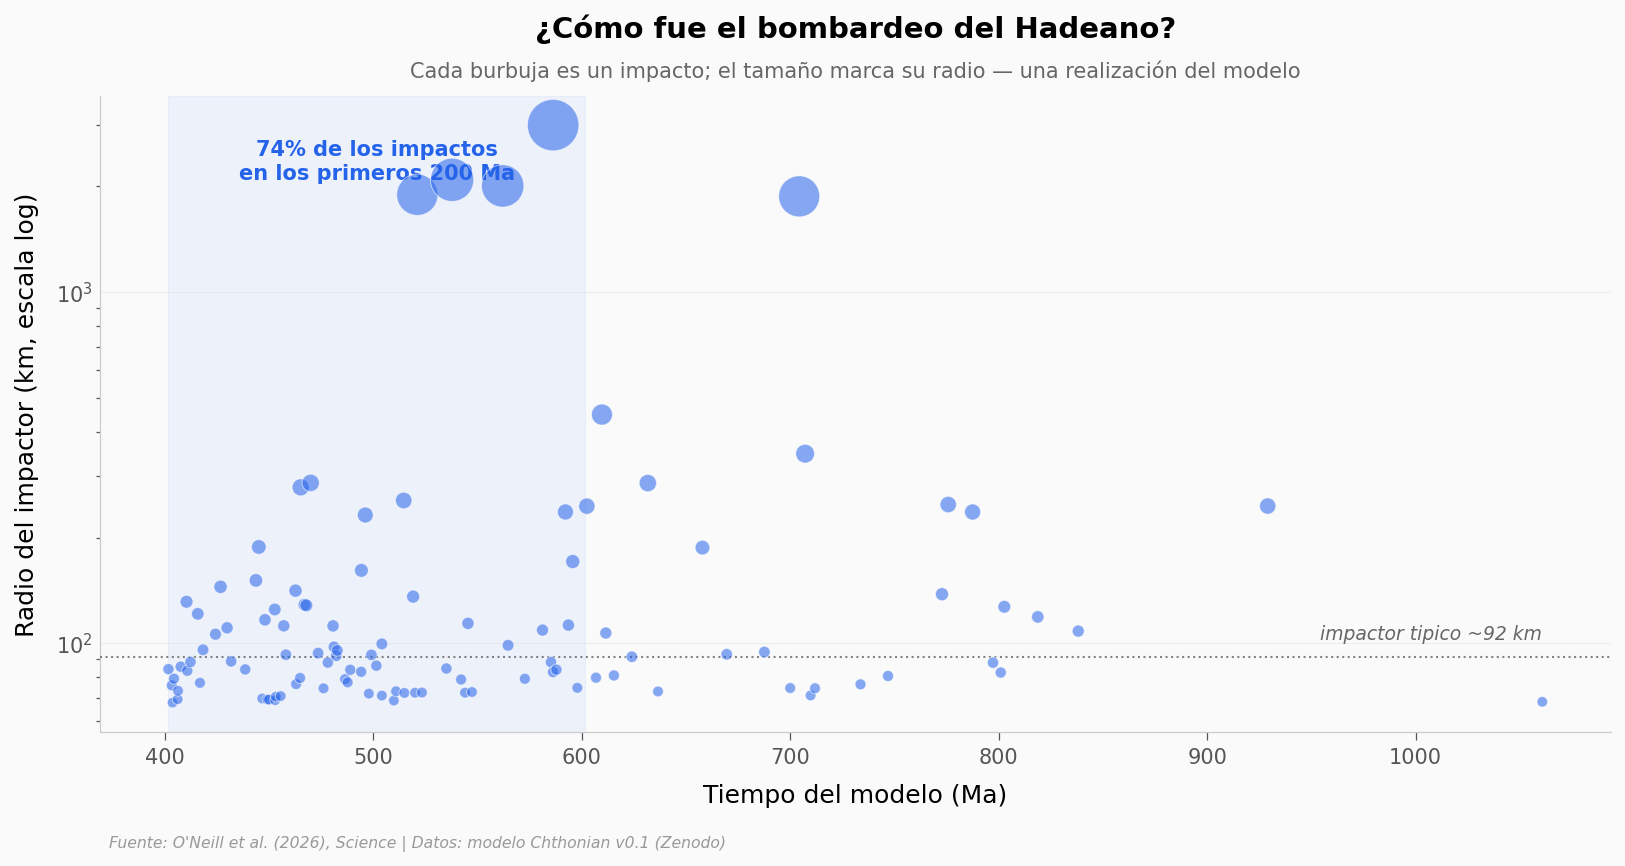

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

t = impactos['edad_modelo_ma']
# Tamano del punto proporcional al radio (escalado para que los gigantes resalten)
sizes = (impactos['radio_km'] / impactos['radio_km'].max()) * 600 + 12

# Sombrear los primeros 200 Ma de la ventana del modelo (donde se concentra el grueso)
t0 = t.min()
ax.axvspan(t0, t0 + 200, color=COLOR_DATOS, alpha=0.06, zorder=0)
ax.text(t0 + 100, 2100, '74% de los impactos\nen los primeros 200 Ma',
        fontsize=10, color=COLOR_DATOS, ha='center', fontweight='bold')

ax.scatter(t, impactos['radio_km'], s=sizes, color=COLOR_DATOS, alpha=0.55,
           edgecolors='white', linewidths=0.5, zorder=5)

# Mediana de tamano como referencia
med = impactos['radio_km'].median()
ax.axhline(y=med, color='#666666', linewidth=1.0, linestyle=':', alpha=0.8, zorder=4)
ax.text(t.max(), med*1.12, f'impactor tipico ~{med:.0f} km',
        fontsize=9, color='#666666', ha='right', style='italic')

ax.set_yscale('log')
ax.set_xlabel('Tiempo del modelo (Ma)')
ax.set_ylabel('Radio del impactor (km, escala log)')
ax.set_title('¿Cómo fue el bombardeo del Hadeano?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada burbuja es un impacto; el tamaño marca su radio — una realización del modelo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

FUENTE = "Fuente: O'Neill et al. (2026), Science | Datos: modelo Chthonian v0.1 (Zenodo)"
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/bombardeo.png', dpi=200, bbox_inches='tight')
plt.show()

En esta realización del modelo cayeron **109 impactores** sobre la franja que estudia (la banda ecuatorial, no el planeta entero — ojo con eso). El grueso se amontona al principio: tres de cada cuatro caen en los primeros 200 millones de años de la ventana, y luego el goteo se calma.

La mayoría son rocas de unos **90 km de radio** — ya de por sí monstruos, comparables al objeto que acabó con los dinosaurios multiplicado por nueve. Pero fíjate en la escala logarítmica del eje vertical: arriba del todo asoman unos pocos puntos enormes. El modelo, por azar, también deja caer un puñado de gigantes de más de 1.000 km. Esos son la excepción, no la regla.

## ¿Cuánto calienta un golpe así?

Un tamaño es solo media historia. La otra mitad es la **velocidad**: cuando un impactor choca, su energía cinética se convierte en una onda de choque que comprime y calienta la roca de golpe.

El modelo usa una fórmula clásica (Melosh, 1989) para estimar el salto de temperatura justo debajo del cráter, en lo que se llama el *núcleo isobárico* — la zona donde la presión del choque es máxima y uniforme. Veamos cuánto sube esa temperatura según la velocidad del impacto.

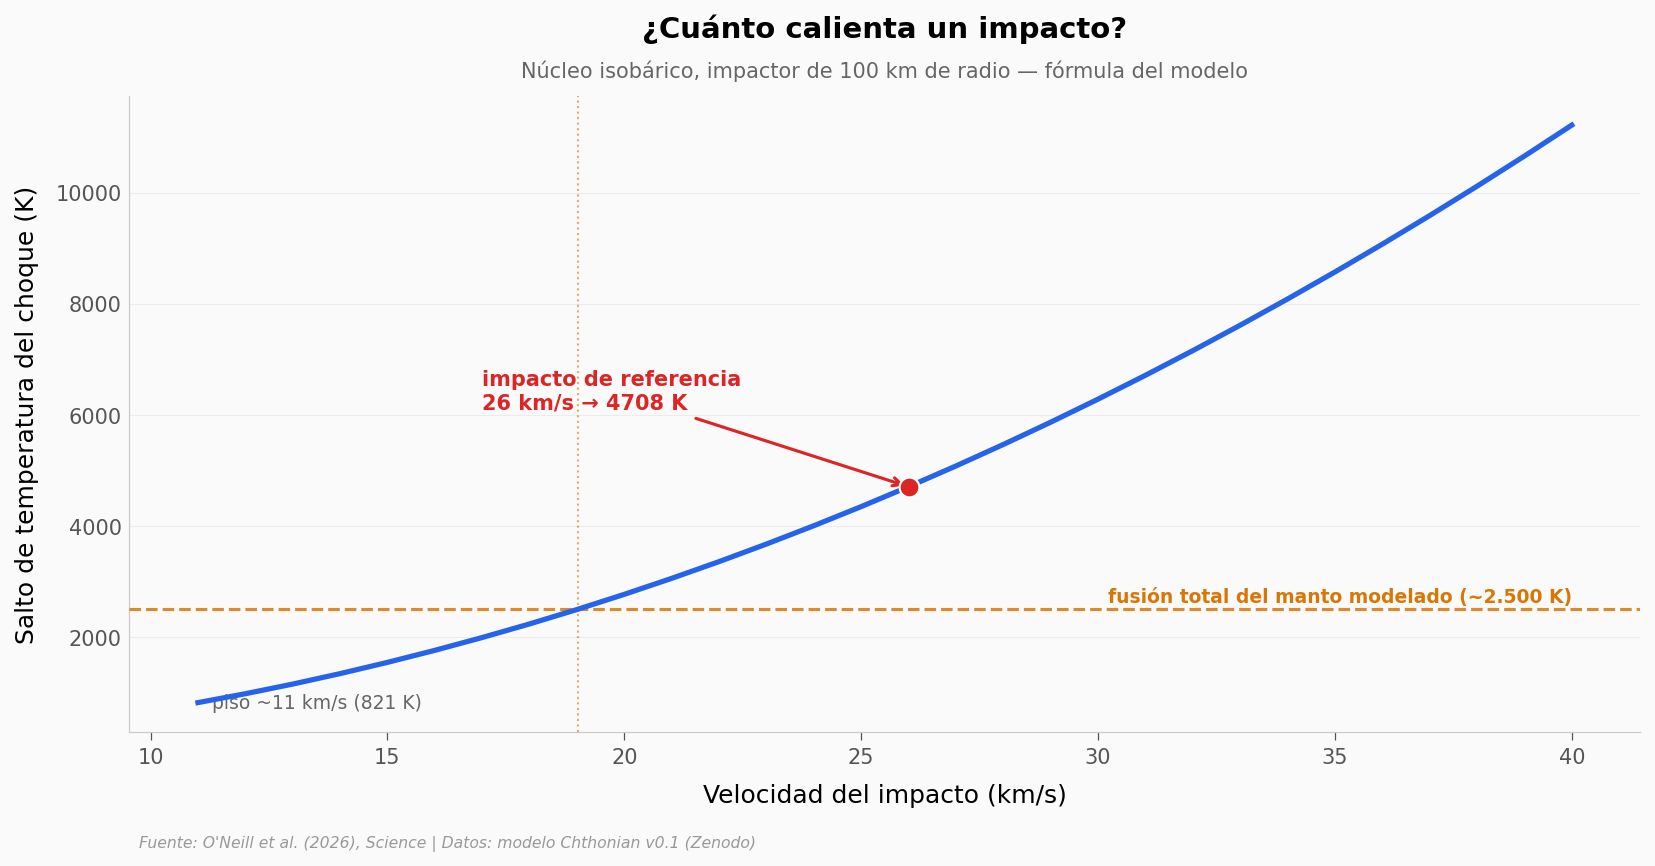

El umbral de fusión total se cruza a ~19 km/s; el impacto de referencia (26 km/s) lo supera 1.9x


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

v = calent['velocidad_km_s']
dT = calent['dT_pico_k']
ax.plot(v, dT, color=COLOR_DATOS, linewidth=2.5, zorder=5)

# Umbral: fusion total del manto modelado
ax.axhline(y=SOLIDUS_MAX, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.85, zorder=3)
ax.text(v.max(), SOLIDUS_MAX*1.05, 'fusión total del manto modelado (~2.500 K)',
        fontsize=9, color=COLOR_REFERENCIA, ha='right', fontweight='bold')

# Velocidad de cruce del umbral
cruce = np.interp(SOLIDUS_MAX, dT, v)
ax.axvline(x=cruce, color=COLOR_REFERENCIA, linewidth=1.0, linestyle=':', alpha=0.6, zorder=2)

# Caso de referencia (26 km/s)
dT_ref = float(calent.loc[calent['velocidad_km_s'] == VEL_REFERENCIA, 'dT_pico_k'].values[0])
ax.scatter([VEL_REFERENCIA], [dT_ref], color=COLOR_ALERTA, s=90, zorder=7,
           edgecolors='white', linewidths=1.0)
ax.annotate(f'impacto de referencia\n{VEL_REFERENCIA} km/s → {dT_ref:.0f} K',
            xy=(VEL_REFERENCIA, dT_ref), xytext=(VEL_REFERENCIA-9, dT_ref+1400),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

# Piso de velocidad
dT_piso = float(calent['dT_pico_k'].iloc[0])
ax.text(v.min()+0.3, dT_piso, f'piso ~{v.min():.0f} km/s ({dT_piso:.0f} K)',
        fontsize=9, color='#666666', va='center')

ax.set_xlabel('Velocidad del impacto (km/s)')
ax.set_ylabel('Salto de temperatura del choque (K)')
ax.set_title('¿Cuánto calienta un impacto?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Núcleo isobárico, impactor de 100 km de radio — fórmula del modelo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/calentamiento.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"El umbral de fusión total se cruza a ~{cruce:.0f} km/s; el impacto de referencia ({VEL_REFERENCIA} km/s) lo supera {dT_ref/SOLIDUS_MAX:.1f}x")

Un detalle que sorprende: en este modelo, ese salto de temperatura **no depende del tamaño del impactor**. Una roca de 50 km y una de 500 km producen el mismo pico de temperatura en su núcleo — lo que cambia es *cuánto volumen* calientan (a eso volvemos al final).

Así que quedémonos con la cifra del impacto de referencia: unos **4.700 K**. La pregunta natural es hasta qué profundidad alcanza ese calor para fundir roca. Para eso necesitamos saber a qué temperatura empieza a fundirse el manto a cada profundidad.

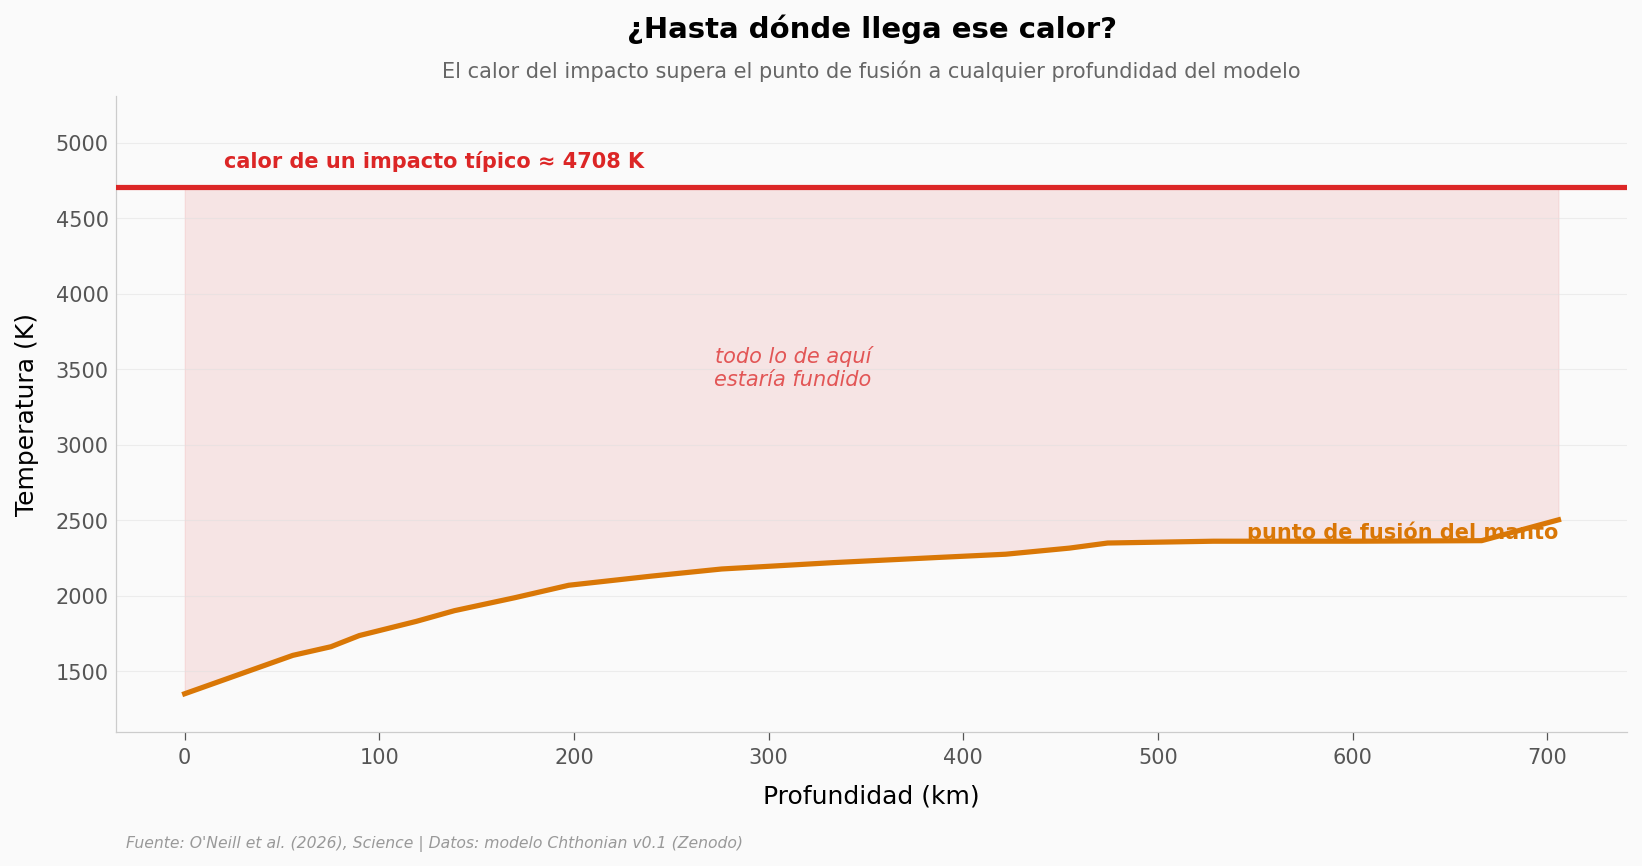

In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

prof = solidus['profundidad_km']
Tsol = solidus['temperatura_solidus_k']

# Calor de un impacto de referencia
dT_ref = float(calent.loc[calent['velocidad_km_s'] == VEL_REFERENCIA, 'dT_pico_k'].values[0])

# Zona que el calor del impacto deja por encima del punto de fusion = fundida
ax.fill_between(prof, Tsol, dT_ref, color=COLOR_ALERTA, alpha=0.10, zorder=1)

ax.plot(prof, Tsol, color=COLOR_REFERENCIA, linewidth=2.5, zorder=5)
ax.text(prof.iloc[-1], Tsol.iloc[-1]-120, 'punto de fusión del manto',
        fontsize=10, color=COLOR_REFERENCIA, ha='right', fontweight='bold')

ax.axhline(y=dT_ref, color=COLOR_ALERTA, linewidth=2.5, zorder=6)
ax.text(prof.min()+20, dT_ref+130, f'calor de un impacto típico ≈ {dT_ref:.0f} K',
        fontsize=10, color=COLOR_ALERTA, fontweight='bold')

ax.text(prof.mean(), (dT_ref + Tsol.mean())/2, 'todo lo de aquí\nestaría fundido',
        fontsize=10, color=COLOR_ALERTA, ha='center', alpha=0.75, style='italic')

ax.set_xlabel('Profundidad (km)')
ax.set_ylabel('Temperatura (K)')
ax.set_ylim(1100, dT_ref + 600)
ax.set_title('¿Hasta dónde llega ese calor?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'El calor del impacto supera el punto de fusión a cualquier profundidad del modelo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/solidus.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo típico y lo monstruoso

Vimos que el impactor típico ronda los 90 km, pero que el modelo también escupe algún gigante. ¿Qué tan torcida está esa distribución de tamaños? Aquí está, contada.

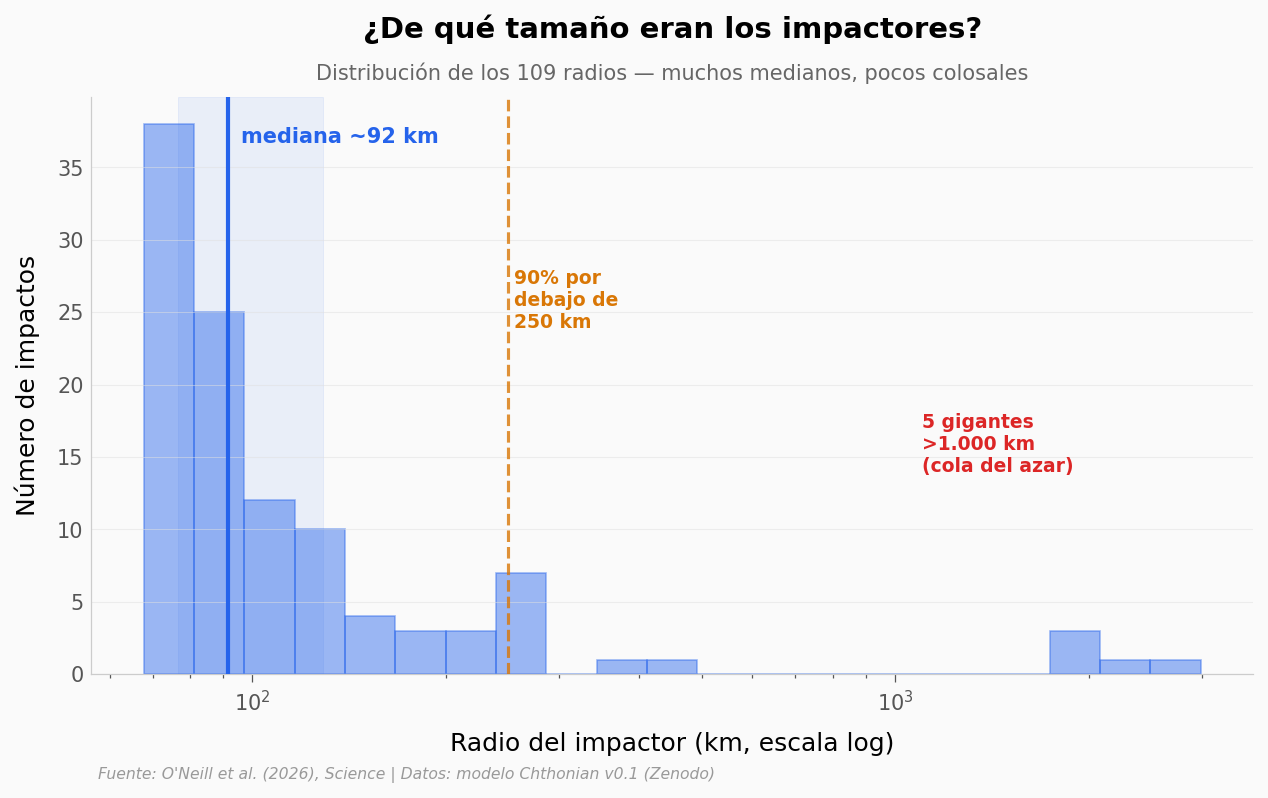

Mediana 91.6 km | IQR 77-129 km | max 2988 km (cola estocástica tamaño-Marte)


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

rad = impactos['radio_km']
# Escala log en X por el enorme rango (67 km a ~3.000 km)
bins = np.logspace(np.log10(rad.min()), np.log10(rad.max()), 22)
ax.hist(rad, bins=bins, color=COLOR_DATOS, alpha=0.45,
        edgecolor=COLOR_DATOS, linewidth=0.8)
ax.set_xscale('log')

med = rad.median()
q1, q3 = rad.quantile(0.25), rad.quantile(0.75)
y_max = ax.get_ylim()[1]
ax.axvspan(q1, q3, color=COLOR_DATOS, alpha=0.08, zorder=0)
ax.axvline(x=med, color=COLOR_DATOS, linewidth=2.0, zorder=5)
ax.text(med*1.05, y_max*0.92, f'mediana ~{med:.0f} km',
        fontsize=10, color=COLOR_DATOS, fontweight='bold')

# Linea del 90% por debajo de 250 km
ax.axvline(x=250, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.8, zorder=4)
ax.text(255, y_max*0.6, '90% por\ndebajo de\n250 km',
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold')

# Cola de gigantes
n_gig = (rad > 1000).sum()
ax.text(1100, y_max*0.35, f'{n_gig} gigantes\n>1.000 km\n(cola del azar)',
        fontsize=9, color=COLOR_ALERTA, fontweight='bold')

ax.set_xlabel('Radio del impactor (km, escala log)')
ax.set_ylabel('Número de impactos')
ax.set_title('¿De qué tamaño eran los impactores?', fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de los 109 radios — muchos medianos, pocos colosales',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_tamanos.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Mediana {med:.1f} km | IQR {q1:.0f}-{q3:.0f} km | max {rad.max():.0f} km (cola estocástica tamaño-Marte)")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| En el modelo caen 109 impactores; mediana ~92 km, 90% por debajo de 250 km | ✅ | Catálogo del modelo (banda ecuatorial). IQR 76–129 km. La cola llega a ~3.000 km, pero es 1 caso |
| El 74% de los impactos del modelo ocurre en los primeros 200 Ma de la ventana | ✅ | Conteo directo sobre la columna de tiempo del modelo |
| Un impacto típico (100 km, 26 km/s) eleva la temperatura unos 4.700 K | ✅ | Fórmula de Melosh (1989) con las constantes verbatim del código del modelo |
| Ese calor supera el punto de fusión del manto a toda profundidad (~1,9×) | ✅ | Solidus máx ~2.500 K a 706 km; 4.708 / 2.502 = 1,9. Conecta con "extensamente fundida bajo unos pocos km" |
| El salto de temperatura no depende del tamaño; el calor *total* escala con ~R³ | ✅ | El núcleo isobárico tiene temperatura uniforme; el volumen calentado crece con el cubo del radio |
| El calor de impacto integrado habría *superado* al calor interno del Hadeano | ⚠️ | Es la conclusión cualitativa del **modelo del paper**, no la recalculamos aquí (requeriría velocidades por impactor y un modelo radiogénico) |

> **Limitaciones.** (1) Son las salidas de **una** realización estocástica de la **banda ecuatorial**, no el flujo global del planeta. (2) Las edades están en "tiempo de modelo" (Ma), sin calibrar a una fecha de calendario. (3) El núcleo isobárico es una simplificación de la física real del impacto. (4) El radio máximo (~3.000 km, tamaño Marte) es una cola del azar: no es un impacto típico ni sostiene el resultado. (5) Reproducimos los datos publicados y la fórmula del modelo, no corremos el solver geodinámico.

## Ahora tú

Los datos están cargados; cámbialos y mira qué pasa.

1. **¿A qué velocidad un impacto deja de fundir el manto entero?** Baja `VEL_REFERENCIA` en la celda de configuración y vuelve a correr la gráfica de calentamiento. ¿Por debajo de qué velocidad el punto rojo cae bajo la línea ámbar?

2. **¿Cuánto más calienta un gigante que un impactor típico?** La celda de abajo grafica la energía térmica relativa según el radio. Prueba comparando un impactor de 90 km con uno de 1.000 km.

3. **¿Cómo cambia el bombardeo si miras solo los grandes?** En la gráfica del catálogo, filtra `impactos[impactos['radio_km'] > 200]` antes de dibujar. ¿Siguen amontonados al principio?

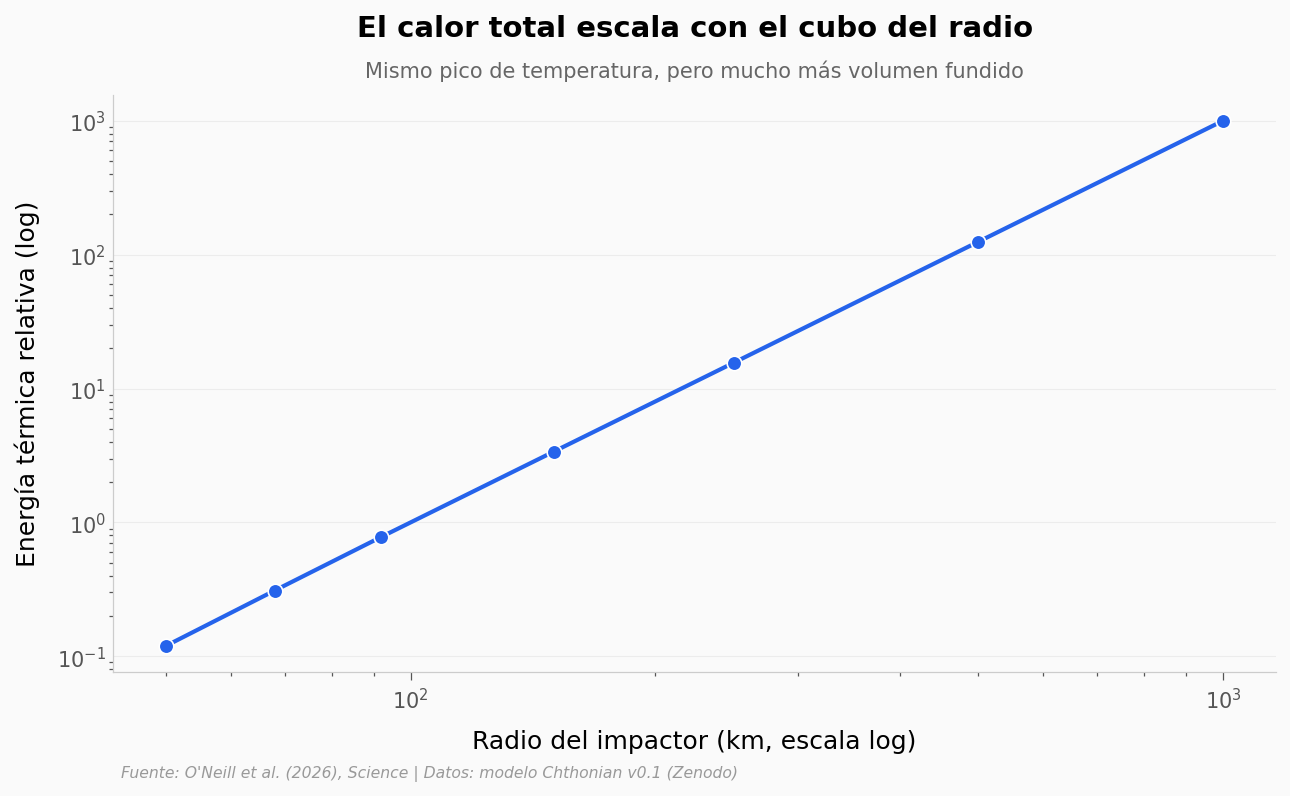

Un impactor de 1000 km libera ~1350x más calor que uno de 90 km
(comparación con el escalado cúbico esperado: (1000/90)^3 = 1372x)


In [6]:
# --- EXPERIMENTA AQUÍ ---
# El salto de temperatura no depende del tamaño, pero el CALOR TOTAL sí:
# crece con el volumen del núcleo isobárico, es decir, con ~R^3.
RADIO_A = 90     # km — un impactor típico
RADIO_B = 1000   # km — un gigante de la cola

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tamano['radio_km'], tamano['energia_termica_relativa'],
        'o-', color=COLOR_DATOS, linewidth=2, markersize=7,
        markeredgecolor='white', markeredgewidth=0.8, zorder=5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Radio del impactor (km, escala log)')
ax.set_ylabel('Energía térmica relativa (log)')
ax.set_title('El calor total escala con el cubo del radio',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Mismo pico de temperatura, pero mucho más volumen fundido',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Comparar dos radios elegidos
e_a = np.interp(RADIO_A, tamano['radio_km'], tamano['energia_termica_relativa'])
e_b = np.interp(RADIO_B, tamano['radio_km'], tamano['energia_termica_relativa'])
ratio = e_b / e_a
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/calor_vs_tamano.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Un impactor de {RADIO_B} km libera ~{ratio:.0f}x más calor que uno de {RADIO_A} km")
print(f"(comparación con el escalado cúbico esperado: ({RADIO_B}/{RADIO_A})^3 = {(RADIO_B/RADIO_A)**3:.0f}x)")

---

## Fuentes

**Paper**: [Impact heating and the hidden Hadean](https://doi.org/10.1126/science.aeb5402)  
*Science, 2026-06-25*

**Dataset canónico**: [thecraigoneill/Chthonian: v0.1 (modelo geodinamico Hadeano: catalogo de impactos, curva solidus, formula de calentamiento)](https://doi.org/10.5281/zenodo.18919910)

**Referencias citadas**: [ComputationalThermodynamics/MAGEMin v1.3.6 (termodinamica de fusion mantelica usada por el modelo)](https://doi.org/10.5281/zenodo.10573416)

*14 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com) · Repo: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab) · Datos del modelo bajo su licencia original.*